## Анализ различий сегментов отельного рынка на основе данных о бронированиях

Цель - провести анализ различий сегментов отельного рынка

In [224]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats as st

def print_hist(data, bins_count, size, plot_title, x_name, y_name):
    data.hist(bins = bins_count, figsize=size)
    plt.grid(True)
    plt.title(plot_title)
    plt.xlabel(x_name)
    plt.ylabel(y_name)
    plt.show()

### Открытие файла и изучение общей информации

In [225]:
pd.set_option('display.max_columns', None)
df = pd.read_csv('/content/hotel_bookings.csv')

In [226]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [227]:
df.head(10)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03
5,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03
6,Resort Hotel,0,0,2015,July,27,1,0,2,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,0,No Deposit,NaN,NaN,0,Transient,107.0,0,0,Check-Out,2015-07-03
7,Resort Hotel,0,9,2015,July,27,1,0,2,2,0.0,0,FB,PRT,Direct,Direct,0,0,0,C,C,0,No Deposit,303.0,NaN,0,Transient,103.0,0,1,Check-Out,2015-07-03
8,Resort Hotel,1,85,2015,July,27,1,0,3,2,0.0,0,BB,PRT,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,82.0,0,1,Canceled,2015-05-06
9,Resort Hotel,1,75,2015,July,27,1,0,3,2,0.0,0,HB,PRT,Offline TA/TO,TA/TO,0,0,0,D,D,0,No Deposit,15.0,NaN,0,Transient,105.5,0,0,Canceled,2015-04-22


* Пустые значения есть в столбцах children, country, agent, company. При этом столбцы agent и company не будут использованы при дальнейшем анализе.
* Столбец children имеет тип float, что не является логичным (не может быть 1.5 ребенка). Позже нужно будет поменять тип на int.



#### Подробнее рассмотрим столбцы

##### Столбец hotel

In [228]:
df['hotel'].unique()

array(['Resort Hotel', 'City Hotel'], dtype=object)

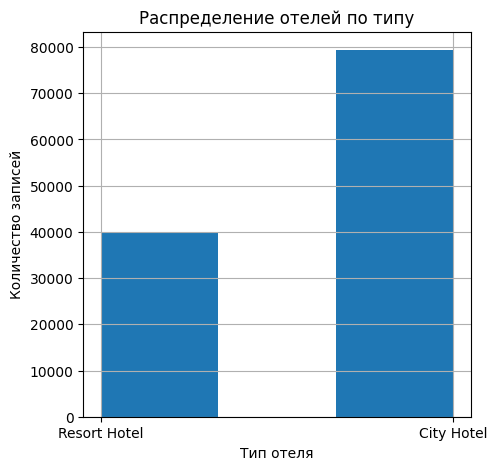

In [229]:
print_hist(df['hotel'], 3, (5, 5), 'Распределение отелей по типу', 'Тип отеля', 'Количество записей')

По графику видно, что бронирований в городские отели почти в 2 раза больше, чем в курортные отели. Но записей по обоим классам достаточно много, поэтому можно принебречь этим фактом.

##### Столбец is_canceled

In [230]:
df['is_canceled'].unique()

array([0, 1])

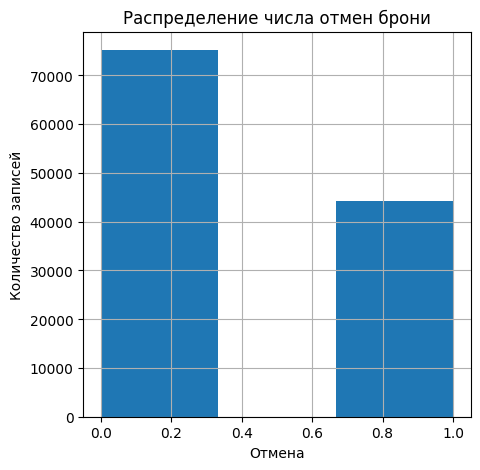

In [231]:
print_hist(df['is_canceled'], 3, (5, 5), 'Распределение числа отмен брони', 'Отмена', 'Количество записей')

По графику видно, что количество отменных бронирований составляет около трети от общего числа.

##### Столбец lead_time

In [232]:
df['lead_time'].describe()

,lead_time
count,119390.000000
mean,104.011416
std,106.863097
min,0.000000
25%,18.000000
50%,69.000000
75%,160.000000
max,737.000000


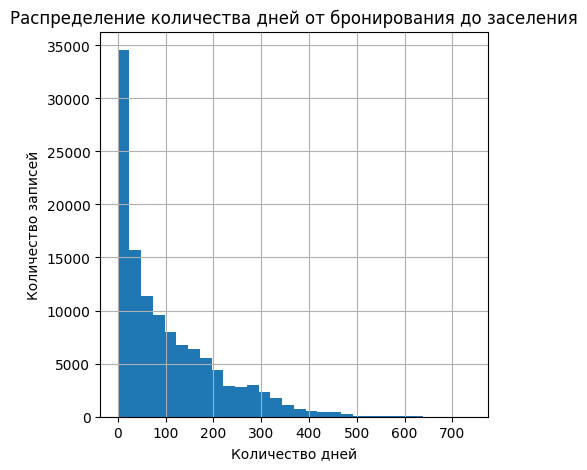

In [233]:
print_hist(df['lead_time'], 30, (5, 5), 'Распределение количества дней от бронирования до заселения', 'Количество дней', 'Количество записей')

Видно, что пик количества записей достигается в значении 0, то есть посетители бронировали номер в отеле в день заселения. Большая часть гостей бронировали отели за примерно 70 дней до приезда. Однако наблюдается длинный хвост с аномальными значениями бронирования за два года до заселения, также видно сильное расхождение среднего значения и медианы. В дальнейшем можно категоризировать этот признак.

##### Столбец arrival_date_year

In [234]:
year_counts = df['arrival_date_year'].value_counts().sort_index()
year_counts

,count
arrival_date_year,
2015,21996
2016,56707
2017,40687


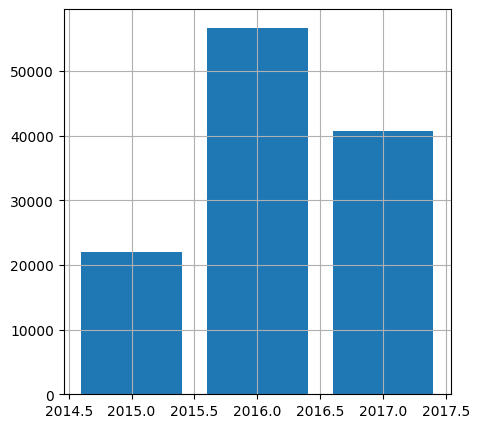

In [235]:
fig = plt.subplots(figsize=(5, 5))
plt.bar(year_counts.index, year_counts.values)
plt.grid(True)

In [236]:
df.groupby(['arrival_date_year', 'arrival_date_month'])['arrival_date_month'].agg('count')

arrival_date_year  arrival_date_month
2015               August                3889
                   December              2920
                   July                  2776
                   November              2340
                   October               4957
                   September             5114
2016               April                 5428
                   August                5063
                   December              3860
                   February              3891
                   January               2248
                   July                  4572
                   June                  5292
                   March                 4824
                   May                   5478
                   November              4454
                   October               6203
                   September             5394
2017               April                 5661
                   August                4925
                   February              4177
                   January               3681
                   July                  5313
                   June                  5647
                   March                 4970
                   May                   6313
Name: arrival_date_month, dtype: int64

В датасете представлены данные за 2015-2017 года, при этом только 2016 год представлен полностью, вероятно, именно поэтому больше всего бронирований было в этом году.

##### Столбец adr

In [237]:
df['adr'].describe()

,adr
count,119390.000000
mean,101.831122
std,50.535790
min,-6.380000
25%,69.290000
50%,94.575000
75%,126.000000
max,5400.000000


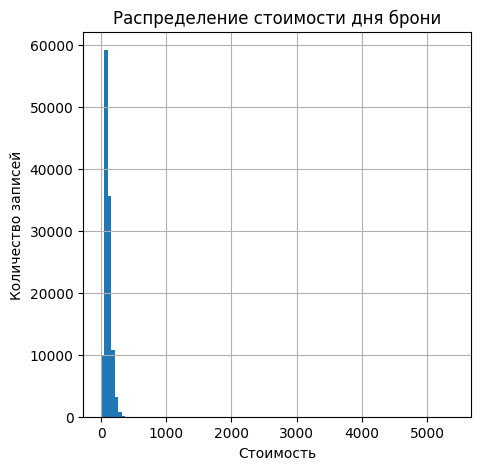

In [238]:
print_hist(df['adr'], 100, (5, 5), 'Распределение стоимости дня брони', 'Стоимость', 'Количество записей')

Есть отрицательные значения (что не логично для значения стоимости) и очень большие значения, выбивающиеся из общей выборки

In [239]:
df[df['adr'] > 500].head(5)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
15083,Resort Hotel,0,1,2015,July,29,15,0,1,2,0.0,0,BB,PRT,Corporate,Corporate,1,0,1,A,C,0,No Deposit,NaN,NaN,0,Transient,508.0,1,0,Check-Out,2015-07-16
48515,City Hotel,1,35,2016,March,13,25,0,1,2,0.0,0,BB,PRT,Offline TA/TO,TA/TO,0,0,0,A,A,1,Non Refund,12.0,NaN,0,Transient,5400.0,0,0,Canceled,2016-02-19
111403,City Hotel,0,0,2017,May,19,9,0,1,1,0.0,0,BB,ITA,Offline TA/TO,TA/TO,0,0,0,A,G,0,No Deposit,159.0,NaN,0,Transient,510.0,0,0,Check-Out,2017-05-10


Заметно, что очень маленькая часть запись заходит за предел 1000 доллларов в день и искажает представление распределения, поэтому позже преобразуем такие записи. Также есть одна запись с отрицательным значением adr, посмотрев на остальные значения в этой строке, можно предположить, что это ошибка ввода данных, поэтому преобразуем число в положительное.

### Заполнение пропущенных значений

Заполним пустые значения в столбце children самым распространенным значением - 0.

In [240]:
df['children'] = df['children'].fillna(0)

Также поступим с пустыми значениями с стоблце country

In [241]:
country_counts = df['country'].value_counts()
country_counts

,count
country,
PRT,48590
GBR,12129
FRA,10415
ESP,8568
DEU,7287
...,...
MRT,1
KIR,1
SDN,1


In [242]:
df['country'].isna().sum()

np.int64(488)

In [243]:
df['country'] = df['country'].fillna('PRT')

Пропуски остальных столбцов, включающих в себя пустые значения - company, agent - заполнять не будем, так как они не будут участвовать в анализе.

### Приведение данных к нужному типу

Приведем столбец children к типу int

In [244]:
df['children'] = df['children'].astype('int')

In [245]:
df['children'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 119390 entries, 0 to 119389
Series name: children
Non-Null Count   Dtype
--------------   -----
119390 non-null  int64
dtypes: int64(1)
memory usage: 932.9 KB


### Категоризация параметра

Разобьём время от бронирования до заселения в отель на категории:

In [246]:
def lead_time_group(lead_time):
  if lead_time <= 7:
    return 'очень короткое'
  elif lead_time <= 30:
    return 'короткое'
  elif lead_time <= 180:
    return 'среднее'
  elif lead_time <= 365:
    return 'длинное'
  else:
    return 'очень длинное'

Создадим новый столбец, характеризующий время от бронирования до заселения в отель, в формате разработанных категорий.

In [247]:
df['lead_time_group'] = df['lead_time'].apply(lead_time_group)

### Преобразование аномальных значений

Для столбца adr преобразуем значения, большие 1000, разделив на 10

In [248]:
df.loc[df['adr'] > 1000,'adr'] = df.loc[df['adr'] > 1000,'adr'] / 10

In [249]:
df['adr'] = df['adr'].apply('abs')

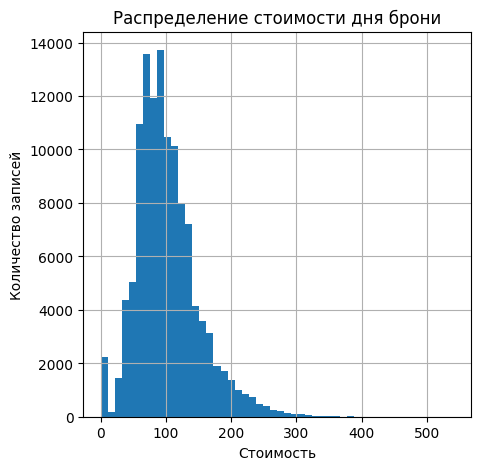

In [250]:
print_hist(df['adr'], 50, (5, 5), 'Распределение стоимости дня брони', 'Стоимость', 'Количество записей')

### Подготовка данных к анализу

Добавим столбец с расчётом стоимости брони в день на гостя

In [251]:
df['adr_per_person'] = df['adr']

In [252]:
df.loc[(df['adults'] + df['children'] + df['babies']) > 0,'adr_per_person'] = df['adr'] / (df['adults'] + df['children'] + df['babies'])

In [253]:
df['adr_per_person'].describe()

,adr_per_person
count,119390.000000
mean,54.901513
std,28.096473
min,0.000000
25%,37.400000
50%,49.500000
75%,66.000000
max,510.000000


### Анализ данных

##### Рассмотрим распределение стоимости брони на одну персону по месяцам и типу отеля, рассчитав среднее значение

In [254]:
monthly_adr_per_person = df.groupby(['hotel', 'arrival_date_year', 'arrival_date_month'])[['adr_per_person']].agg(['mean']).reset_index()
monthly_adr_per_person.columns = ['hotel', 'arrival_date_year', 'arrival_date_month', 'adr_per_person_mean']
monthly_adr_per_person

,hotel,arrival_date_year,arrival_date_month,adr_per_person_mean
0,City Hotel,2015,August,40.850140
1,City Hotel,2015,December,47.594998
2,City Hotel,2015,July,37.533858
3,City Hotel,2015,November,52.258690
4,City Hotel,2015,October,55.887821
5,City Hotel,2015,September,60.865594
6,City Hotel,2016,April,54.286304
7,City Hotel,2016,August,54.392692
8,City Hotel,2016,December,48.688230
9,City Hotel,2016,February,47.879782


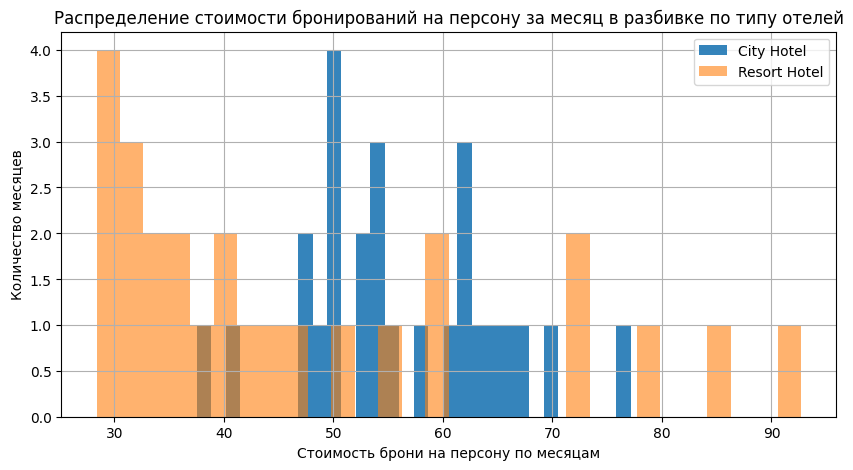

In [255]:
monthly_adr_per_person[monthly_adr_per_person['hotel'] == 'City Hotel']['adr_per_person_mean'].hist(bins=30, figsize=(10, 5), alpha = 0.9)
monthly_adr_per_person[monthly_adr_per_person['hotel'] == 'Resort Hotel']['adr_per_person_mean'].hist(bins=30, alpha = 0.6)
plt.grid(True)
labels= ["City Hotel","Resort Hotel"]
plt.legend(labels)
plt.title('Распределение стоимости бронирований на персону за месяц в разбивке по типу отелей')
plt.xlabel('Стоимость брони на персону по месяцам')
plt.ylabel('Количество месяцев')
plt.show()

По графику можно сказать, что средняя стоимость брони за сутки на одного человека в зависимости от месяца для курортных отелей имеет сильный разброс по значениям, однако чаще дешевле, чем для городских отелей.

##### Рассмотрим распределение посетителей с детьми в зависимости от разных типов отелей

In [256]:
children = df.groupby(['hotel'])[['children', 'babies']].agg(['sum', 'count']).reset_index()
children.columns = ['hotel', 'children_sum', 'children_count', 'babies_sum', 'babies_count']
children['general_part'] = (children['children_sum'] + children['babies_sum']) / (children['children_count'] + children['babies_count'])
children['children_part'] = children['children_sum'] / children['children_count']
children['babies_part'] = children['babies_sum'] / children['babies_count']
children

,hotel,children_sum,children_count,babies_sum,babies_count,general_part,children_part,babies_part
0,City Hotel,7248,79330,392,79330,0.048153,0.091365,0.004941
1,Resort Hotel,5155,40060,557,40060,0.071293,0.128682,0.013904


По распределению можно сказать, что бронирующие с детьми чаще выбирают курортные отели. То есть среди потенциальных посетителей курортных отелей на 48% больше посетителей с детьми, чем для городских отелей.

##### Проверим распределение отмен в зависимости от типа внесенной предоплаты

In [257]:
canceled_deposit = df.groupby(['hotel', 'deposit_type'])['is_canceled'].agg(['count', 'sum']).reset_index()
canceled_deposit.columns = ['hotel', 'deposit_type', 'count', 'sum']
canceled_deposit['share_of_cancellation'] = canceled_deposit['sum'] / canceled_deposit['count']
canceled_deposit

,hotel,deposit_type,count,sum,share_of_cancellation
0,City Hotel,No Deposit,66442,20244,0.304687
1,City Hotel,Non Refund,12868,12844,0.998135
2,City Hotel,Refundable,20,14,0.700000
3,Resort Hotel,No Deposit,38199,9450,0.247389
4,Resort Hotel,Non Refund,1719,1650,0.959860
5,Resort Hotel,Refundable,142,22,0.154930


По распределению видно, что значительно чаще происходят отмены бронирований с частичной или полной предоплатой, однако такое соотношение может быть связано с политикой отелей (бронь исключительно по предоплате).

##### Рассмотрим распределение отмен брони в зависимости от количества дней от дня брони до заселения в отель

In [258]:
lead_time_cancellations = df.groupby(['lead_time_group'])['is_canceled'].agg(['sum', 'count']).reset_index()
lead_time_cancellations.columns = ['lead_time_group', 'sum', 'count']
lead_time_cancellations['part'] = lead_time_cancellations['sum'] / lead_time_cancellations['count']
lead_time_cancellations.sort_values(by='part', ascending=False)

,lead_time_group,sum,count,part
2,очень длинное,2130,3148,0.676620
0,длинное,11947,21544,0.554540
4,среднее,22962,55992,0.410094
1,короткое,5283,18960,0.278639
3,очень короткое,1902,19746,0.096323


По распределению видно, что чем больше дней от дня бронирования до заселения, тем больше доля отмен.

Рассмотрим это  распределение на графике, используя величину lead_time

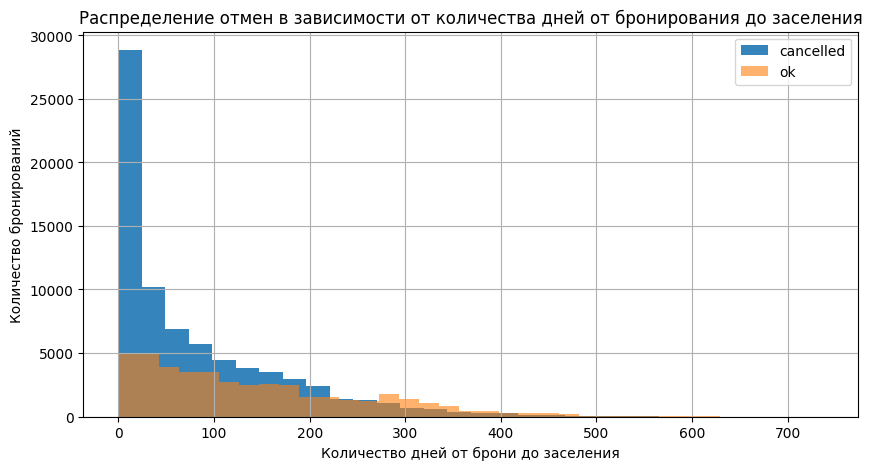

In [259]:
df[df['is_canceled'] == 0]['lead_time'].hist(bins=30, figsize=(10, 5), alpha = 0.9)
df[df['is_canceled'] == 1]['lead_time'].hist(bins=30, alpha = 0.6)
plt.grid(True)
labels= ["cancelled","ok"]
plt.legend(labels)
plt.title('Распределение отмен в зависимости от количества дней от бронирования до заселения')
plt.xlabel('Количество дней от брони до заселения')
plt.ylabel('Количество бронирований')
plt.show()

По графику видно, что доля отмены с увеличением дней от брони до заселения постепенно растет, а когда приближается и переходит за границу года до заселения, то отмены происходят чаще, чем успешные брони.

##### Рассмотрим распределение стоимости одного дня проживания в отеле на человека в зависимости от количества дней от бронирования до заселения

In [260]:
lead_time_adr = df.groupby(['lead_time_group'])['adr_per_person'].agg(['mean']).reset_index()
lead_time_adr.columns = ['lead_time_group', 'mean']
lead_time_adr.sort_values(by='mean')

,lead_time_group,mean
2,очень длинное,42.790050
0,длинное,48.912091
4,среднее,55.825323
3,очень короткое,55.857162
1,короткое,59.994697


По распределению можно сделать вывод, что более раннее бронирование выгоднее, чем срочное.

### Проверка гипотез

Необходимо проверить следующие гипотезы:
* средняя стоимость брони в день на одного человека для курортных и городских отелей различается
* доля отмен для курортных и городских отелей различается

##### Для проверки первой гипотезы разделим данные на выборку курортных отелей и городских отелей. Для выбора критерия проверки гипотезы сравним получившиеся распределения выборок с нормальным распределением.

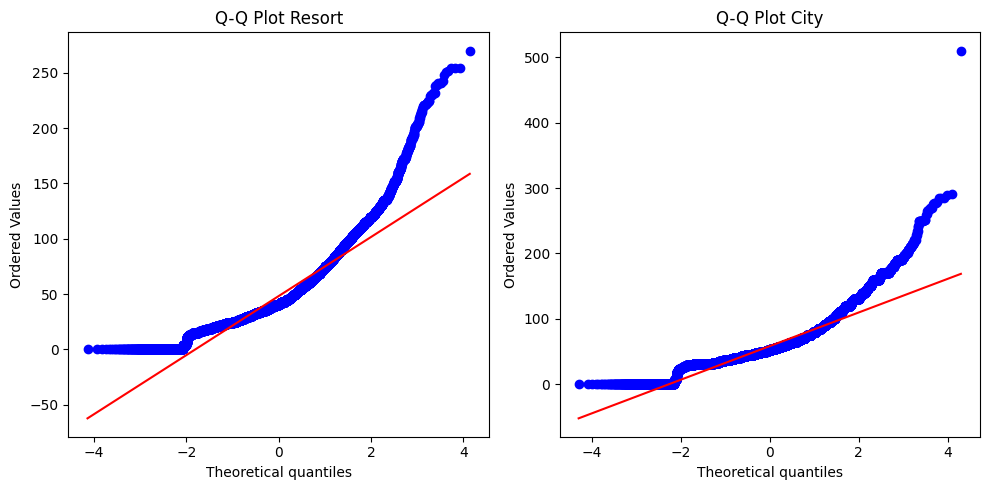

In [261]:
from scipy import stats

resort = df[df['hotel'] == 'Resort Hotel']['adr_per_person']
city = df[df['hotel'] == 'City Hotel']['adr_per_person']

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

stats.probplot(resort, dist="norm", plot=axes[0])
axes[0].set_title('Q-Q Plot Resort')

stats.probplot(city, dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot City')

plt.tight_layout()
plt.show()

Получившиеся распределения имеют не нормальное распределение, поэтому будет использоваться непараметрический тест Манна-Уитни.  Нулевая гипотеза H0: средние значения стоимости брони в день на одного человека для курортных и городских отелей совпадают. Альтернативная гипотеза H1: средние значения стоимости брони в день на одного человека для курортных и городских отелей различаются.

In [262]:
adr_per_person_by_hotel = df.groupby(['hotel'])['adr_per_person'].agg('mean')
adr_per_person_by_hotel

,adr_per_person
hotel,
City Hotel,58.276818
Resort Hotel,48.217464


In [263]:
alpha = 0.05

results = stats.mannwhitneyu(resort, city, alternative='two-sided')
print(results.pvalue)

if (results.pvalue < alpha):
  print('Отвергаем нулевую гипотезу.')
else:
  print('Нулевая гипотезы не отвергается.')

0.0
Отвергаем нулевую гипотезу.


По результату теста можно сделать вывод, что средние стоимости брони в день на человека курортных и городских отелей будут равны, является нулевой. Следовательно, средние стоимости действительно различны.

##### Для проверки второй гипотезы будет проведен Z-тест. Нулевая гипотеза H0: доля отмен бронирований для курортных и городских отелей совпадают. Альтернативная гипотеза H1: доля отмен бронирований для курортных и городских отелей различаются.

In [264]:
cancel_partition = df.groupby(['hotel'])['is_canceled'].agg(['sum', 'count'])
cancel_partition['part'] = cancel_partition['sum'] / cancel_partition['count']
cancel_partition

,sum,count,part
hotel,,,
City Hotel,33102,79330,0.417270
Resort Hotel,11122,40060,0.277634


In [265]:
from statsmodels.stats.proportion import proportions_ztest

crosstab = pd.crosstab(df['hotel'], df['is_canceled'])

alpha = 0.05
z_stat, p_value = proportions_ztest(
    count=[crosstab.loc['Resort Hotel', 1], crosstab.loc['City Hotel', 1]],
    nobs=[crosstab.loc['Resort Hotel'].sum(), crosstab.loc['City Hotel'].sum()]
)

print(p_value)
if (p_value < alpha):
  print("Нулевая гипотеза отвергается.")
else:
  print("Нулевая гипотеза не отвергается.")

0.0
Нулевая гипотеза отвергается.


По результату теста можно сделать вывод, что вероятность равенства долей отмененных бронирований от общего числа бронирований является нулевой. То есть между долей отмен бронирований в курортных и городских отелях есть различия.

### Общие выводы

* Средняя стоимость брони в отель в городе примерно на 20% выше, чем в курортный отель
* Отмен бронирований для гороских отелей примерно на 50% больше, чем для курортных отелей
* Средняя стоимость брони в день меньше при более раннем бронировании
* Доля отмен растет при увеличении срока от бронирования до заселения